# 男女中風資料變項分析與比較

本 Notebook 旨在利用 pandas 與 Seaborn 套件對男、女兩組臨床資料進行探索性資料分析（EDA）。

主要內容包括：
1. 根據中風再發（Second_Stroke）的狀態，比較 LDL、cholesterol、HbA1c 等變項的箱型圖分佈
2. 比較兩性在 NIHSS 評分上的分佈（核密度圖及箱型圖）

請確認同資料夾中有 `male_data.csv` 與 `female_data.csv` 這兩個檔案。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 設定 Seaborn 主題
sns.set(style="whitegrid")

# 讀取男性與女性資料（請依實際路徑調整）
male_df = pd.read_csv('./raw_data/male_data.csv')
female_df = pd.read_csv('./raw_data/female_data.csv')

# 將 Second_Stroke 欄位的 0/1 轉換為 No/Yes（方便圖表顯示）
male_df['Second_Stroke'] = male_df['Second_Stroke'].map({0: 'No', 1: 'Yes'})
female_df['Second_Stroke'] = female_df['Second_Stroke'].map({0: 'No', 1: 'Yes'})

# 為方便後續比較，新增性別欄位
male_df['Gender'] = 'Male'
female_df['Gender'] = 'Female'

# 合併男女資料
combined_df = pd.concat([male_df, female_df], ignore_index=True)

# 檢查部分資料內容
print("Male Data Description:\n", male_df.describe())
print("\nFemale Data Description:\n", female_df.describe())

Male Data Description:
               age    sex        HLOS       NIHSS    tPA(0/1)    EVT(0/1)  \
count  916.000000  916.0  916.000000  916.000000  916.000000  916.000000   
mean    66.491266    0.0   14.792576    5.775109    0.078603    0.077511   
std     12.353577    0.0   14.308566    6.774242    0.269265    0.267546   
min     23.000000    0.0    0.000000    0.000000    0.000000    0.000000   
25%     59.000000    0.0    6.000000    1.000000    0.000000    0.000000   
50%     68.000000    0.0    9.000000    3.000000    0.000000    0.000000   
75%     75.000000    0.0   19.000000    7.000000    0.000000    0.000000   
max     94.000000    0.0  107.000000   39.000000    1.000000    1.000000   

         HTN(0/1)     DM(0/1)  Dyslipidemia(0/1)     Af(0/1)  smoking(Y/N/Q)  \
count  916.000000  916.000000         916.000000  916.000000      916.000000   
mean     0.759825    0.385371           0.682314    0.175764        0.623362   
std      0.427423    0.486949           0.465831   

## 1. LDL、Cholesterol 與 HbA1c 與中風再發的箱型圖

以下分別根據中風再發（Second_Stroke）狀態，繪製男性與女性患者的 LDL、cholesterol 與 HbA1c 的箱型圖。

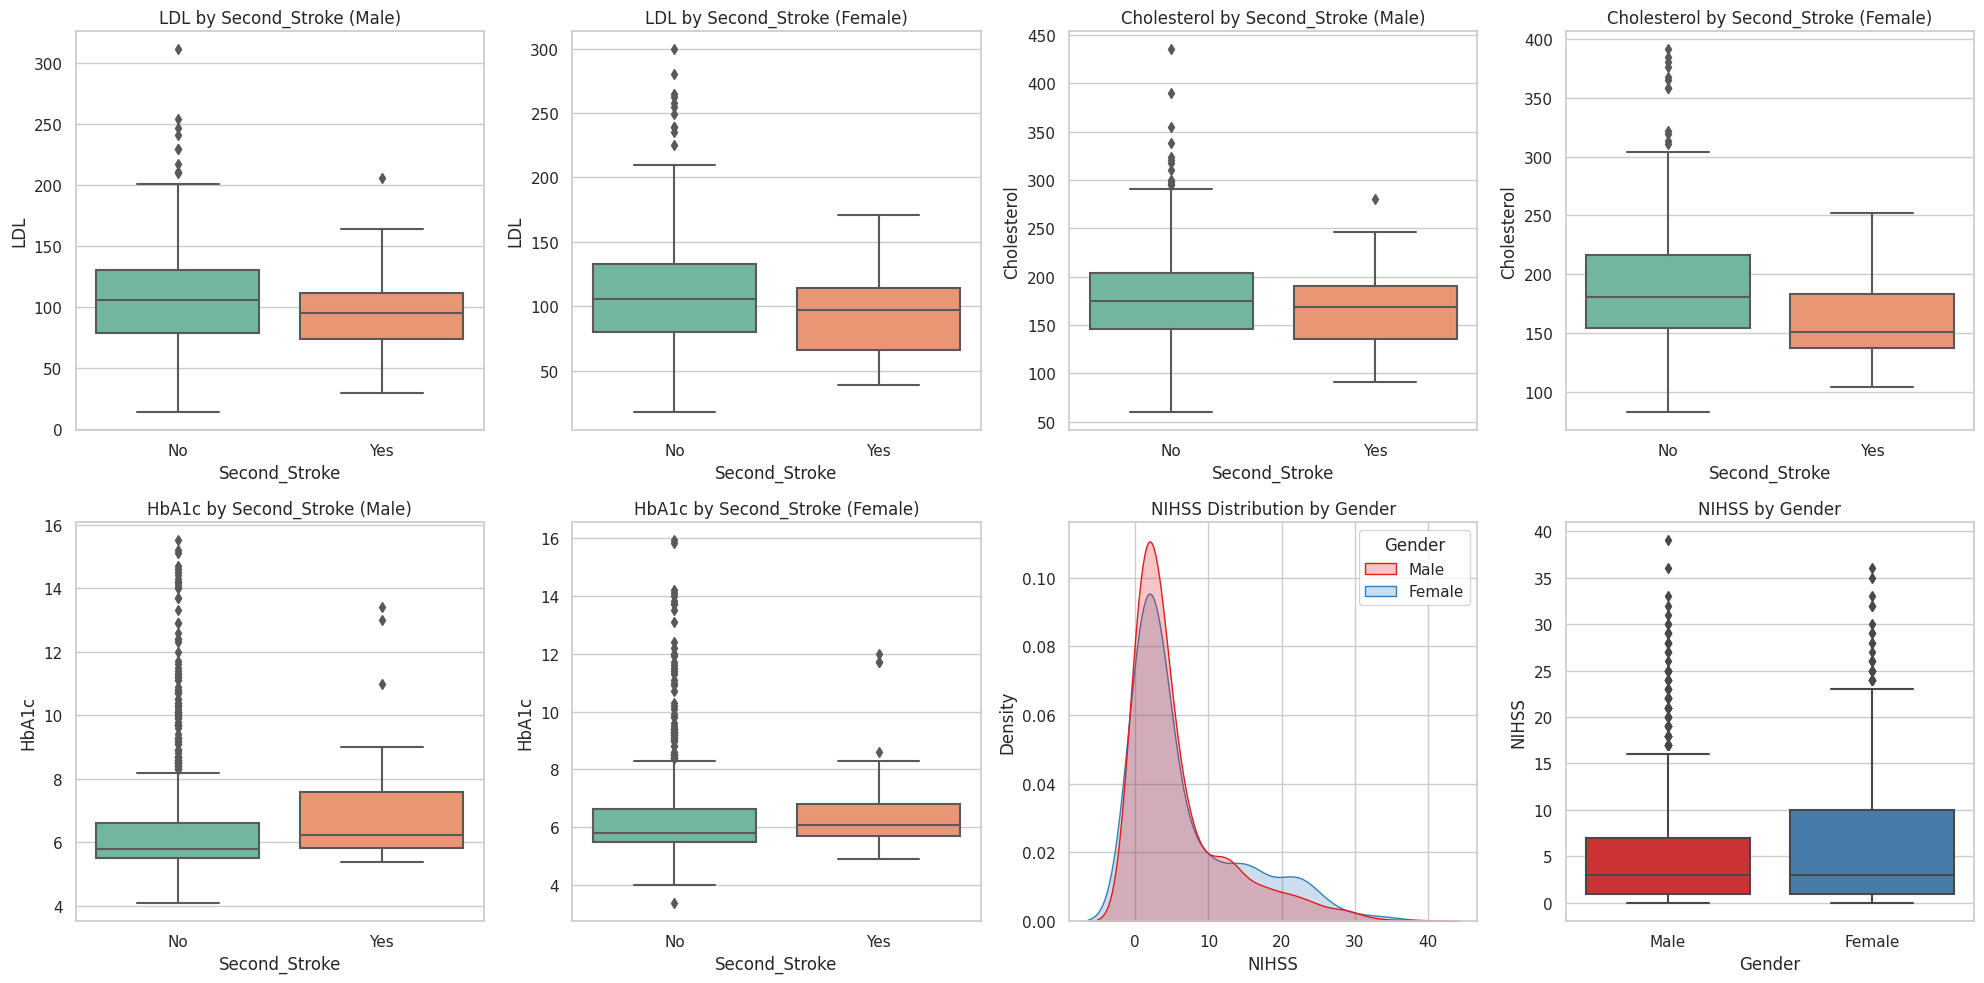

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

############################################
# (1) LDL vs Second_Stroke (Male)
############################################
sns.boxplot(
    data=male_df,
    x='Second_Stroke',
    y='LDL ',
    ax=axes[0, 0],
    palette='Set2'
)
axes[0, 0].set_title('LDL by Second_Stroke (Male)')
axes[0, 0].set_xlabel('Second_Stroke')
axes[0, 0].set_ylabel('LDL')

############################################
# (2) LDL vs Second_Stroke (Female)
############################################
sns.boxplot(
    data=female_df,
    x='Second_Stroke',
    y='LDL ',
    ax=axes[0, 1],
    palette='Set2'
)
axes[0, 1].set_title('LDL by Second_Stroke (Female)')
axes[0, 1].set_xlabel('Second_Stroke')
axes[0, 1].set_ylabel('LDL')

############################################
# (3) Cholesterol vs Second_Stroke (Male)
############################################
sns.boxplot(
    data=male_df,
    x='Second_Stroke',
    y='cholesterol',
    ax=axes[0, 2],
    palette='Set2'
)
axes[0, 2].set_title('Cholesterol by Second_Stroke (Male)')
axes[0, 2].set_xlabel('Second_Stroke')
axes[0, 2].set_ylabel('Cholesterol')

############################################
# (4) Cholesterol vs Second_Stroke (Female)
############################################
sns.boxplot(
    data=female_df,
    x='Second_Stroke',
    y='cholesterol',
    ax=axes[0, 3],
    palette='Set2'
)
axes[0, 3].set_title('Cholesterol by Second_Stroke (Female)')
axes[0, 3].set_xlabel('Second_Stroke')
axes[0, 3].set_ylabel('Cholesterol')

############################################
# (5) HbA1c vs Second_Stroke (Male)
############################################
sns.boxplot(
    data=male_df,
    x='Second_Stroke',
    y='HbA1c',
    ax=axes[1, 0],
    palette='Set2'
)
axes[1, 0].set_title('HbA1c by Second_Stroke (Male)')
axes[1, 0].set_xlabel('Second_Stroke')
axes[1, 0].set_ylabel('HbA1c')

############################################
# (6) HbA1c vs Second_Stroke (Female)
############################################
sns.boxplot(
    data=female_df,
    x='Second_Stroke',
    y='HbA1c',
    ax=axes[1, 1],
    palette='Set2'
)
axes[1, 1].set_title('HbA1c by Second_Stroke (Female)')
axes[1, 1].set_xlabel('Second_Stroke')
axes[1, 1].set_ylabel('HbA1c')

############################################
# (7) NIHSS Distribution by Gender (Density Plot)
############################################
sns.kdeplot(
    data=combined_df,
    x='NIHSS',
    hue='Gender',
    ax=axes[1, 2],
    fill=True,
    common_norm=False,
    palette='Set1'
)
axes[1, 2].set_title('NIHSS Distribution by Gender')
axes[1, 2].set_xlabel('NIHSS')
axes[1, 2].set_ylabel('Density')

############################################
# (8) NIHSS by Gender (Boxplot)
############################################
sns.boxplot(
    data=combined_df,
    x='Gender',
    y='NIHSS',
    ax=axes[1, 3],
    palette='Set1'
)
axes[1, 3].set_title('NIHSS by Gender')
axes[1, 3].set_xlabel('Gender')
axes[1, 3].set_ylabel('NIHSS')

# 統一調整圖表佈局
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

# 定義計算單一欄位離群點數量的函式（IQR 方法）
def count_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers.shape[0]

# 讀取資料，請根據你的實際檔案路徑修改檔名
male_df = pd.read_csv('./raw_data/male_data.csv')
female_df = pd.read_csv('./raw_data/female_data.csv')

# 清除欄位名稱前後的空白
male_df.columns = male_df.columns.str.strip()
female_df.columns = female_df.columns.str.strip()

# 如果有需要，可先檢查欄位名稱，確保例如 "LDL", "cholesterol", "HbA1c", "age", "NIHSS", "TG", "Cre", "SGPT", "MRS" 等欄位正確

# 選取數值型欄位（排除明顯為二元分類的欄位）
# 這裡我們將「獨特值數量」大於 10 的欄位視為連續數值型欄位
def filter_numeric_columns(df):
    numeric_cols = df.select_dtypes(include=["number"]).columns
    return [col for col in numeric_cols if df[col].nunique() > 10]

numeric_cols_male = filter_numeric_columns(male_df)
numeric_cols_female = filter_numeric_columns(female_df)

print("計算男性資料中的各欄位離群點數量:")
total_outliers_male = 0
for col in numeric_cols_male:
    outlier_count = count_outliers_iqr(male_df, col)
    print(f"【{col}】: {outlier_count}")
    total_outliers_male += outlier_count

print(f"\n男性資料中總計離群點數: {total_outliers_male}")

print("\n--------------------------------------------\n")

print("計算女性資料中的各欄位離群點數量:")
total_outliers_female = 0
for col in numeric_cols_female:
    outlier_count = count_outliers_iqr(female_df, col)
    print(f"【{col}】: {outlier_count}")
    total_outliers_female += outlier_count

print(f"\n女性資料中總計離群點數: {total_outliers_female}")


計算男性資料中的各欄位離群點數量:
【age】: 8
【HLOS】: 73
【NIHSS】: 87
【LDL】: 10
【cholesterol】: 13
【TG】: 52
【Cre】: 79
【SGPT】: 63
【HbA1c】: 87

男性資料中總計離群點數: 472

--------------------------------------------

計算女性資料中的各欄位離群點數量:
【age】: 13
【HLOS】: 54
【NIHSS】: 25
【LDL】: 11
【cholesterol】: 11
【TG】: 28
【Cre】: 53
【SGPT】: 46
【HbA1c】: 56

女性資料中總計離群點數: 297


## 圖表簡單說明

- **圖表 1 & 2**：分別繪製了男性與女性在 LDL 分佈上依照 `Second_Stroke`（中風再發）狀態的箱型圖。從圖中可見，再次中風組的 LDL 值普遍略偏低，這可能與中風後降脂治療有關。

- **圖表 3 & 4**：展示了男女在 `cholesterol` 分佈上的差異，類似 LDL 的趨勢，也呈現再發患者較低膽固醇值的現象。

- **圖表 5 & 6**：顯示了男女在 `HbA1c` 分佈上的差異，再次中風組普遍有較高的 HbA1c 值，說明血糖控制不佳與中風再發密切相關。

- **圖表 7**：以核密度圖比較男女在 NIHSS 分數上的分佈，觀察到女性患者在初次中風時的嚴重度略高，而男性則較為集中。

- **圖表 8**：用箱型圖比較男女在 NIHSS 分數上的統計特性，包括中位數、四分位數及離群值。

總的來說，這些圖表幫助我們理解不同臨床變項與中風再發之間的關聯性，並展示出男女在數據分佈上的差異。男性資料呈現較高的變異性和更多極端值，意味著在後續建模時可能需要更多的數據清理工作。